# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech
## Business Understanding

### Latar Belakang

Jaya Jaya Institut adalah perguruan tinggi yang sudah berdiri sejak tahun 2000. Selama lebih dari dua dekade, institusi ini sudah meluluskan banyak mahasiswa. Tapi di balik pencapaian itu, ada satu masalah yang belum terpecahkan sampai sekarang: angka **dropout** mahasiswa yang masih terbilang tinggi.

Kalau dibiarkan, dropout yang tinggi berdampak ke banyak hal:
- **Reputasi** - calon mahasiswa dan mitra industri jadi ragu kalau angka dropout tidak terkendali.
- **Finansial** - biaya operasional sudah keluar, tapi mahasiswanya tidak sampai lulus.
- **Sosial** - mahasiswa yang dropout kehilangan peluang karir yang sebenarnya sudah di depan mata.
- **Efisiensi** - beasiswa, fasilitas, dan tenaga pengajar jadi kurang optimal dimanfaatkan.

Solusi yang diusulkan adalah membangun sistem yang bisa **mendeteksi lebih awal** mahasiswa yang berisiko dropout, supaya pihak institusi bisa segera turun tangan sebelum terlambat.

## Permasalahan Bisnis

Berikut empat pertanyaan bisnis yang ingin dijawab dalam proyek ini (mengikuti prinsip SMART):

1. **Berapa besar tingkat dropout** mahasiswa Jaya Jaya Institut **pada periode 2008 sampai 2015**, dan **bagaimana sebarannya** di tiap jurusan?
2. **Faktor demografis dan akademik apa** yang paling berkaitan dengan dropout **berdasarkan data 2008-2015**, sehingga bisa dijadikan **tanda peringatan dini**?
3. **Di semester berapa** (semester 1 atau 2) dropout paling sering terjadi, dan **indikator akademik apa** yang paling bisa memprediksi hal itu?
4. **Seberapa besar pengaruh kondisi finansial** (status bayar UKT, status debitur, penerima beasiswa) terhadap angka dropout **dalam data historis tersebut**?

## Cakupan Proyek

1. Analisis data (EDA) dari berbagai sudut pandang: distribusi, hubungan antar variabel, uji statistik
2. Dashboard bisnis interaktif di Looker Studio
3. Model machine learning prediksi dropout dengan perbandingan 4 algoritma dan pencarian hyperparameter terbaik
4. Prototype aplikasi web di Streamlit Community Cloud

**Target Variabel:** `Status` (binary: `Dropout` = 1, `Graduate` = 0)

**Metrik Utama:** F1-Score dan Recall untuk kelas Dropout, karena lebih penting bisa menangkap mahasiswa yang dropout daripada sekadar akurasi keseluruhan.


## 1. Import Library

Semua library yang dibutuhkan di-import di sini sekaligus. Pastikan sudah install dulu lewat `pip install -r requirements.txt`.


In [65]:
import logging
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, kurtosis, shapiro, skew
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)
logger.info('Library berhasil di-import')


2026-04-23 10:38:45,567 - INFO - Library berhasil di-import


## 2. Load Dataset

Dataset dimuat langsung dari URL repositori Dicoding. Separator yang dipakai adalah titik koma (`;`), bukan koma biasa. Nama kolom juga disesuaikan formatnya: spasi diganti underscore, tanda kurung dihapus.


In [66]:
url = 'https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv'
df = pd.read_csv(url, delimiter=';')

# Standardize column names
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('(', '').str.replace(')', '')

print(f'Dataset berhasil dimuat!')
print(f'Shape: {df.shape[0]} baris x {df.shape[1]} kolom')
print(f'\nDaftar Kolom ({len(df.columns)}):')  
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')

Dataset berhasil dimuat!
Shape: 4424 baris x 37 kolom

Daftar Kolom (37):
   1. Marital_status
   2. Application_mode
   3. Application_order
   4. Course
   5. Daytime_evening_attendance
   6. Previous_qualification
   7. Previous_qualification_grade
   8. Nacionality
   9. Mothers_qualification
  10. Fathers_qualification
  11. Mothers_occupation
  12. Fathers_occupation
  13. Admission_grade
  14. Displaced
  15. Educational_special_needs
  16. Debtor
  17. Tuition_fees_up_to_date
  18. Gender
  19. Scholarship_holder
  20. Age_at_enrollment
  21. International
  22. Curricular_units_1st_sem_credited
  23. Curricular_units_1st_sem_enrolled
  24. Curricular_units_1st_sem_evaluations
  25. Curricular_units_1st_sem_approved
  26. Curricular_units_1st_sem_grade
  27. Curricular_units_1st_sem_without_evaluations
  28. Curricular_units_2nd_sem_credited
  29. Curricular_units_2nd_sem_enrolled
  30. Curricular_units_2nd_sem_evaluations
  31. Curricular_units_2nd_sem_approved
  32. Curricula

In [67]:
print('5 baris pertama dataset:')
df.head()

5 baris pertama dataset:


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3. Eksplorasi Data (EDA)

Di bagian ini kita akan kenali data lebih dalam dari berbagai sisi sebelum masuk ke tahap pemodelan:
1. Statistik deskriptif dasar
2. Pengecekan data kosong dan duplikat
3. Deteksi outlier
4. Melihat rentang nilai tiap fitur
5. Visualisasi distribusi dan hubungan fitur dengan status dropout
6. Uji distribusi (skewness, kurtosis, normalitas)
7. Uji statistik untuk fitur kategorikal (Chi-Square)


### 3.1 Statistik Deskriptif

Langkah pertama adalah melihat ringkasan statistik dasar tiap fitur: rata-rata, nilai minimum, nilai maksimum, dan sebagainya. Ini penting buat punya gambaran awal sebelum masuk ke analisis yang lebih dalam.


In [68]:
# Statistik deskriptif fitur numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [69]:
# Informasi tipe data dan jumlah non-null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [70]:
print('Distribusi kelas target:')
target_counts = df['Status'].value_counts()
target_pct = df['Status'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Jumlah': target_counts,
    'Persentase (%)': target_pct.round(2)
})
print(target_summary)
print(f'\nTotal: {len(df)} mahasiswa')

Distribusi kelas target:
          Jumlah  Persentase (%)
Status                          
Graduate    2209           49.93
Dropout     1421           32.12
Enrolled     794           17.95

Total: 4424 mahasiswa


### 3.2 Pengecekan Data Kosong dan Duplikat

Sebelum lanjut, kita perlu pastikan dulu tidak ada data yang kosong atau baris yang sama persis muncul dua kali. Kalau ada, perlu diputuskan apakah dihapus atau diisi dengan nilai lain.


In [71]:
print('=== Pengecekan Missing Values ===')
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct.round(2)
})
missing_cols = missing_df[missing_df['Missing Count'] > 0]

if missing_cols.empty:
    print('Tidak ada missing values - dataset sudah bersih.')
else:
    print(f'Ditemukan {len(missing_cols)} kolom dengan missing values:')
    print(missing_cols.sort_values('Missing Count', ascending=False))

print(f'\nTotal missing values: {missing_count.sum()}')

=== Pengecekan Missing Values ===
Tidak ada missing values - dataset sudah bersih.

Total missing values: 0


In [72]:
print('=== Pengecekan Data Duplikat ===')
n_dupes = df.duplicated().sum()
print(f'Jumlah baris duplikat: {n_dupes}')

if n_dupes > 0:
    print(f'Menghapus {n_dupes} baris duplikat...')
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Shape setelah penghapusan: {df.shape}')
else:
    print('Tidak ada data duplikat.')

=== Pengecekan Data Duplikat ===
Jumlah baris duplikat: 0
Tidak ada data duplikat.


### 3.3 Deteksi Outlier

Outlier dideteksi menggunakan **metode IQR (Interquartile Range)**:
- Batas bawah = Q1 - 1.5 x IQR
- Batas atas = Q3 + 1.5 x IQR

Nilai di luar rentang itu dianggap outlier. Tapi perlu diingat: tidak semua outlier harus dihapus. Di dataset akademik seperti ini, nilai 0 pada jumlah mata kuliah yang lulus bisa bermakna nyata (mahasiswa tidak ikut ujian), bukan sekadar kesalahan data.


In [73]:
print('Hasil deteksi outlier (IQR method):\n')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude target-like columns

outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
        'Lower Bound': round(lower, 2), 'Upper Bound': round(upper, 2),
        'Outliers': n_out,
        'Pct (%)': round(n_out / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
has_outlier = outlier_df[outlier_df['Outliers'] > 0].sort_values('Outliers', ascending=False)

if has_outlier.empty:
    print('Tidak ditemukan outlier signifikan.')
else:
    print(f'Fitur dengan outlier ({len(has_outlier)} kolom):')
    print(has_outlier.to_string(index=False))

Hasil deteksi outlier (IQR method):

Fitur dengan outlier (28 kolom):
                                     Feature      Q1      Q3  Lower Bound  Upper Bound  Outliers  Pct (%)
                          Scholarship_holder    0.00    0.00         0.00         0.00      1099    24.84
              Curricular_units_2nd_sem_grade   10.75   13.33         6.87        17.21       877    19.82
              Curricular_units_1st_sem_grade   11.00   13.40         7.40        17.00       726    16.41
                      Previous_qualification    1.00    1.00         1.00         1.00       707    15.98
           Curricular_units_1st_sem_credited    0.00    0.00         0.00         0.00       577    13.04
                           Application_order    1.00    2.00        -0.50         3.50       541    12.23
           Curricular_units_2nd_sem_credited    0.00    0.00         0.00         0.00       530    11.98
                     Tuition_fees_up_to_date    1.00    1.00         1.00         

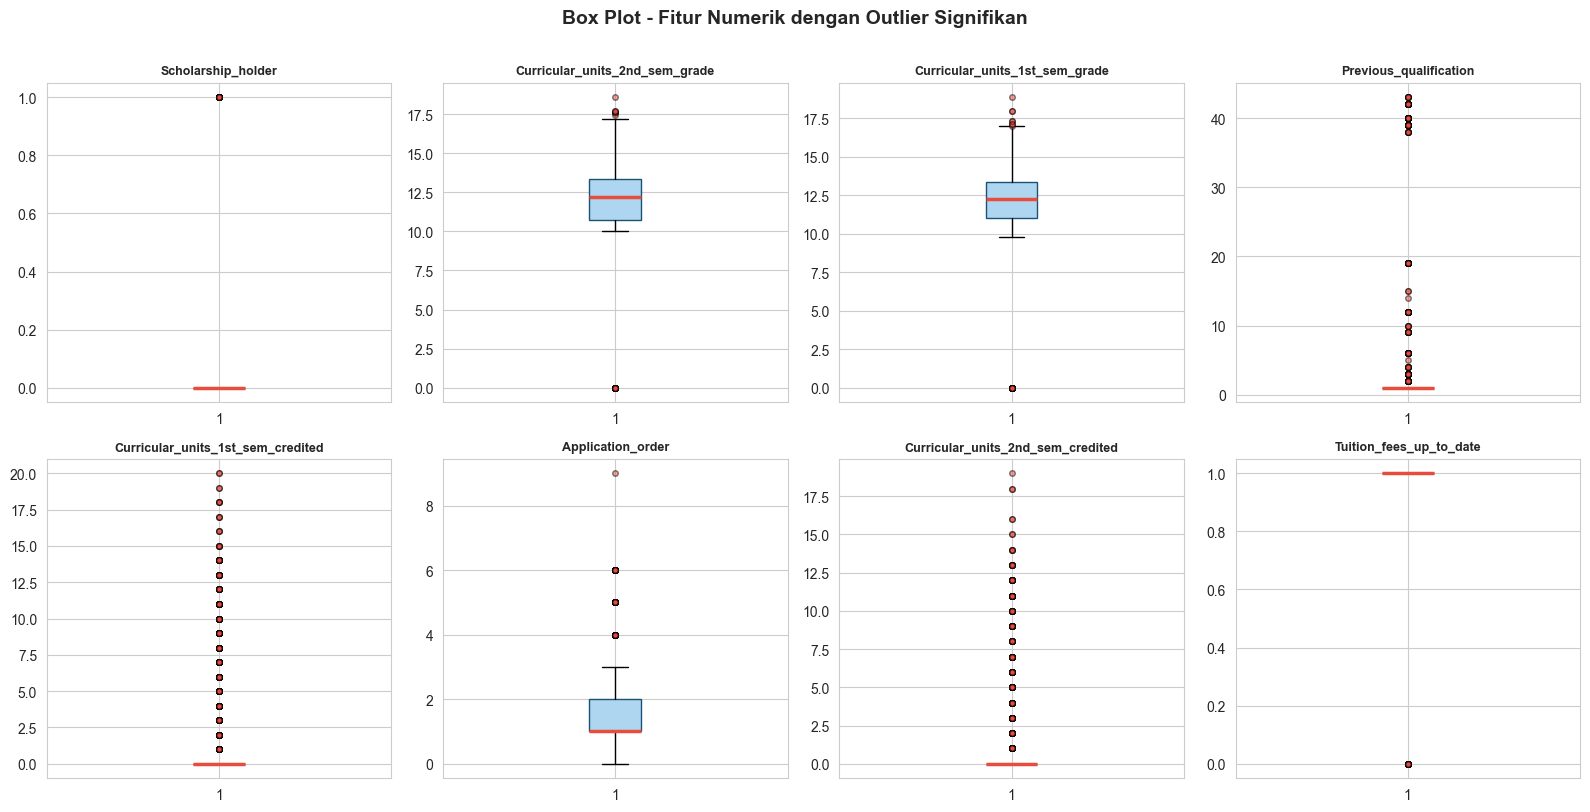

Note: Outlier pada fitur akademik (misal grade=0) bisa bermakna nyata (mahasiswa tidak mengikuti evaluasi).
      Outlier tidak dihapus agar informasi asli tetap terjaga.


In [74]:
# Visualisasi boxplot untuk fitur dengan outlier > 2%
top_out_cols = outlier_df[outlier_df['Pct (%)'] > 2].sort_values('Pct (%)', ascending=False)['Feature'].tolist()

if len(top_out_cols) == 0:
    top_out_cols = outlier_df.sort_values('Pct (%)', ascending=False)['Feature'].head(8).tolist()

top_out_cols = top_out_cols[:8]
n_cols_plot = 4
n_rows_plot = (len(top_out_cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, 4 * n_rows_plot))
axes_flat = axes.flatten() if n_rows_plot > 1 else [axes] if n_cols_plot == 1 else axes.flatten()

for i, col in enumerate(top_out_cols):
    axes_flat[i].boxplot(
        df[col].dropna(), vert=True, patch_artist=True,
        boxprops=dict(facecolor='#AED6F1', color='#1A5276'),
        medianprops=dict(color='#E74C3C', linewidth=2.5),
        flierprops=dict(marker='o', markerfacecolor='#E74C3C', markersize=4, alpha=0.5)
    )
    axes_flat[i].set_title(col, fontsize=9, fontweight='bold')

for j in range(len(top_out_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Box Plot - Fitur Numerik dengan Outlier Signifikan', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ninditya_sna-dashboard/outlier_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: Outlier pada fitur akademik (misal grade=0) bisa bermakna nyata (mahasiswa tidak mengikuti evaluasi).')
print('      Outlier tidak dihapus agar informasi asli tetap terjaga.')

### 3.4 Rentang Nilai Tiap Fitur

Kita cek rentang nilai (nilai minimum dan maksimum) tiap fitur. Fitur dengan rentang yang sangat besar perlu di-scaling supaya model tidak terlalu terpengaruh besarnya angka dan lebih fokus ke polanya.


In [75]:
print('Rentang nilai tiap fitur numerik (fitur dengan range > 50 akan di-scale):\n')

range_data = []
for col in numeric_cols:
    vmin = df[col].min()
    vmax = df[col].max()
    vrange = vmax - vmin
    range_data.append({
        'Feature': col,
        'Min': round(vmin, 2),
        'Max': round(vmax, 2),
        'Range': round(vrange, 2),
        'Mean': round(df[col].mean(), 2),
        'Std': round(df[col].std(), 2),
        'Perlu Scaling': 'Ya' if vrange > 50 else 'Tidak'
    })

range_df = pd.DataFrame(range_data).sort_values('Range', ascending=False)
print(range_df.to_string(index=False))
needs_scaling_count = (range_df['Perlu Scaling'] == 'Ya').sum()
print(f'\nFitur yang perlu scaling: {needs_scaling_count}')
needs_scaling = range_df[range_df['Perlu Scaling'] == 'Ya']['Feature'].tolist()
print(f'\nDaftar fitur yang perlu scaling ({len(needs_scaling)}):')
print(needs_scaling)

Rentang nilai tiap fitur numerik (fitur dengan range > 50 akan di-scale):

                                     Feature   Min     Max   Range    Mean     Std Perlu Scaling
                                      Course 33.00 9991.00 9958.00 8856.64 2063.57            Ya
                          Fathers_occupation  0.00  195.00  195.00   11.03   25.26            Ya
                          Mothers_occupation  0.00  194.00  194.00   10.96   26.42            Ya
                                 Nacionality  1.00  109.00  108.00    1.87    6.91            Ya
                             Admission_grade 95.00  190.00   95.00  126.98   14.48            Ya
                Previous_qualification_grade 95.00  190.00   95.00  132.61   13.19            Ya
                            Application_mode  1.00   57.00   56.00   18.67   17.48            Ya
                           Age_at_enrollment 17.00   70.00   53.00   23.27    7.59            Ya
        Curricular_units_1st_sem_evaluations  0.00  

### 3.5 Visualisasi Data

Sekarang kita lihat distribusi kelas target dan faktor-faktor yang tampaknya punya kaitan dengan status dropout lewat beberapa grafik.


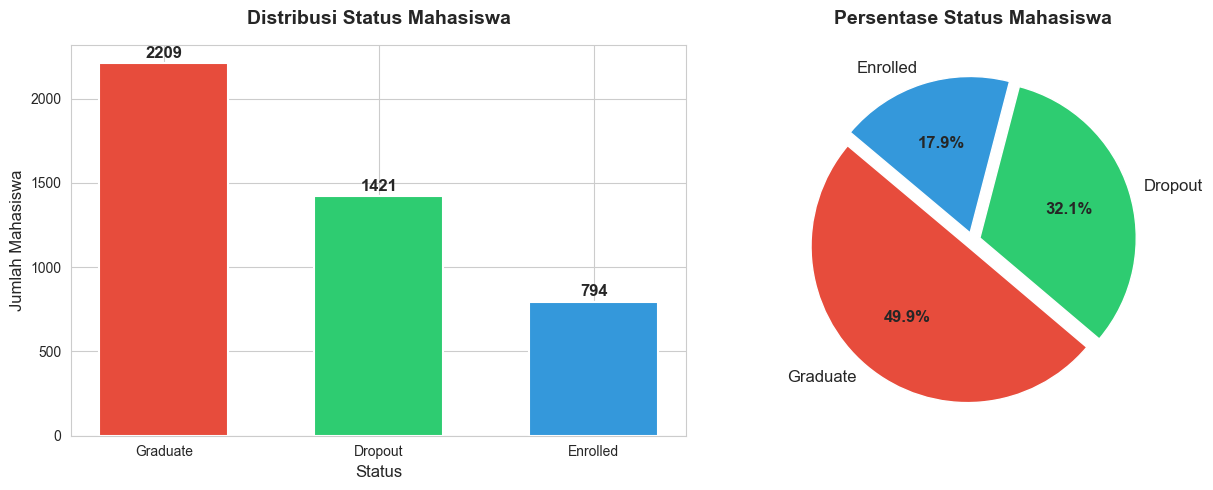

Insight:
  - Graduate: 2209 (49.9%)
  - Dropout: 1421 (32.1%)
  - Enrolled: 794 (17.9%)


In [76]:
# Distribusi target variable
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

status_counts = df['Status'].value_counts()
colors_target = ['#E74C3C', '#2ECC71', '#3498DB']

bars = ax1.bar(status_counts.index, status_counts.values,
               color=colors_target, edgecolor='white', linewidth=1.5, width=0.6)
ax1.set_title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Status', fontsize=12)
ax1.set_ylabel('Jumlah Mahasiswa', fontsize=12)
for bar, val in zip(bars, status_counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 15,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)

wedges, texts, autotexts = ax2.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors_target,
    startangle=140,
    explode=(0.05, 0.05, 0.05),
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
ax2.set_title('Persentase Status Mahasiswa', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('ninditya_sna-dashboard/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Insight:')
for status, count in status_counts.items():
    print(f'  - {status}: {count} ({count/len(df)*100:.1f}%)')

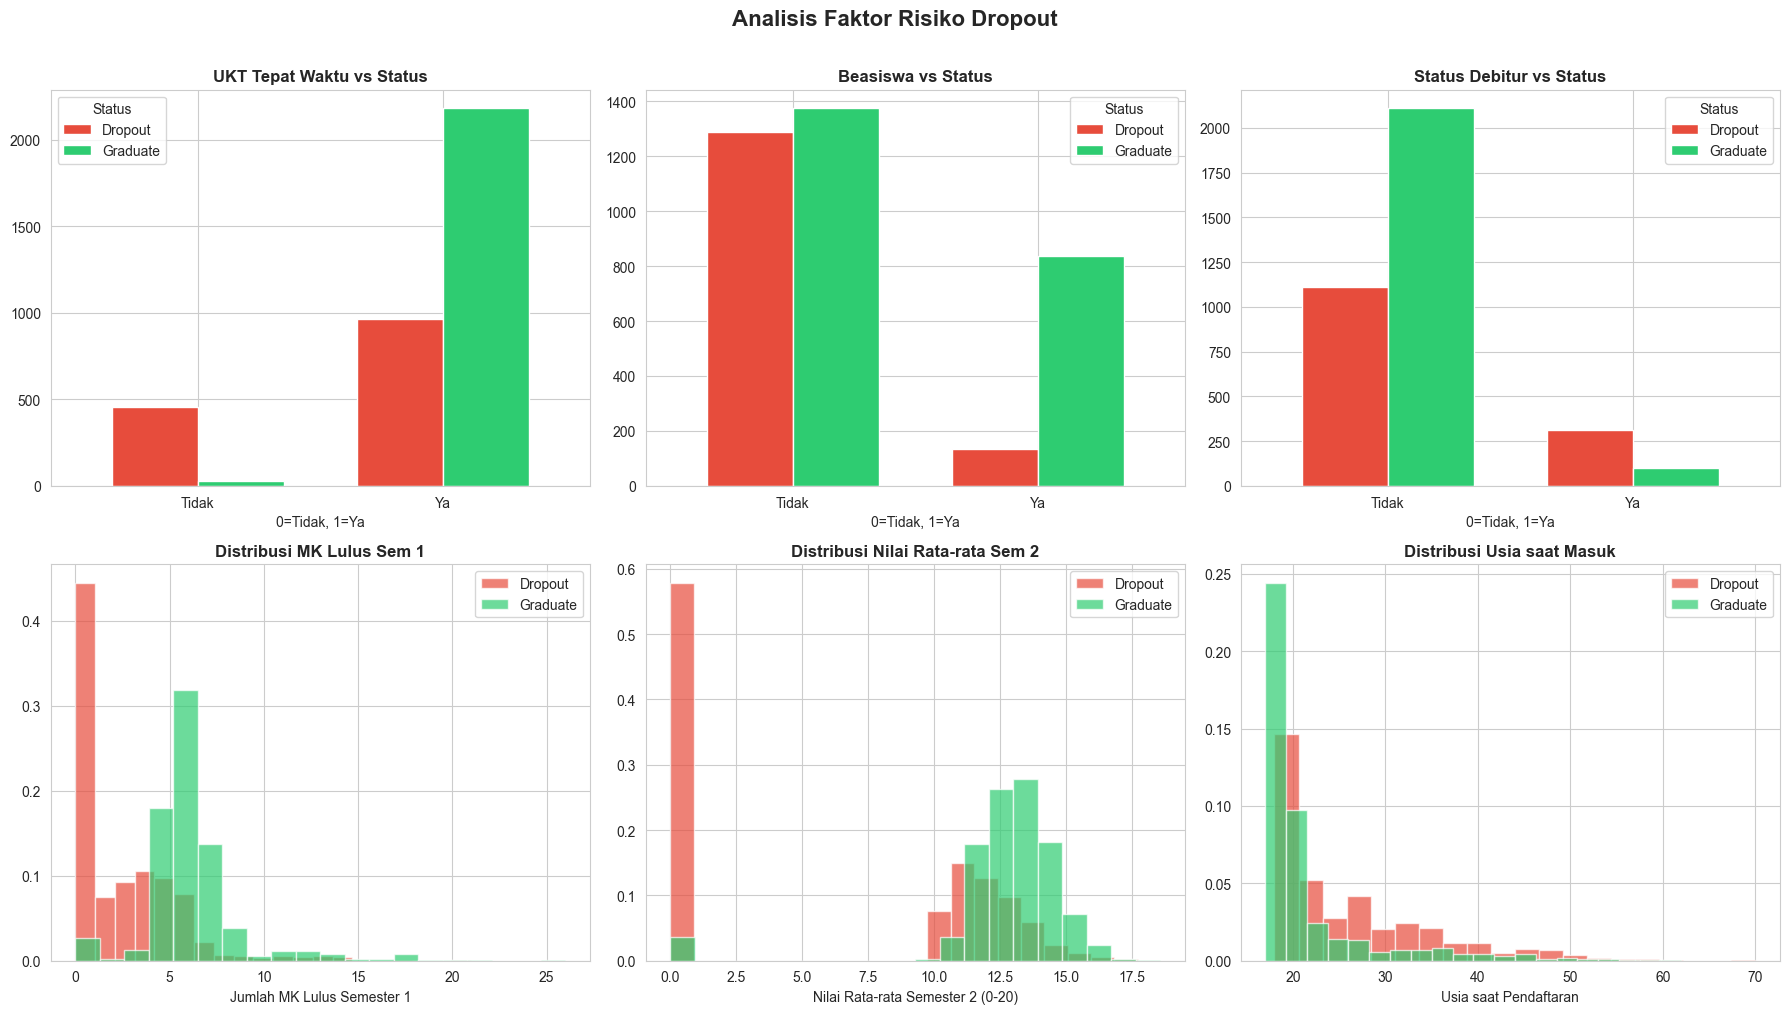

In [77]:
# Analisis bivariate: faktor risiko dropout
df_eda = df[df['Status'].isin(['Graduate', 'Dropout'])].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Tuition Fees vs Status
if 'Tuition_fees_up_to_date' in df_eda.columns:
    tuit = df_eda.groupby(['Tuition_fees_up_to_date', 'Status']).size().unstack(fill_value=0)
    tuit.plot(kind='bar', ax=axes[0, 0], color=['#E74C3C', '#2ECC71'], width=0.7, edgecolor='white')
    axes[0, 0].set_title('UKT Tepat Waktu vs Status', fontweight='bold', fontsize=12)
    axes[0, 0].set_xlabel('0=Tidak, 1=Ya')
    axes[0, 0].set_xticklabels(['Tidak', 'Ya'], rotation=0)
    axes[0, 0].legend(title='Status', loc='upper left')

# 2. Scholarship vs Status
if 'Scholarship_holder' in df_eda.columns:
    sch = df_eda.groupby(['Scholarship_holder', 'Status']).size().unstack(fill_value=0)
    sch.plot(kind='bar', ax=axes[0, 1], color=['#E74C3C', '#2ECC71'], width=0.7, edgecolor='white')
    axes[0, 1].set_title('Beasiswa vs Status', fontweight='bold', fontsize=12)
    axes[0, 1].set_xlabel('0=Tidak, 1=Ya')
    axes[0, 1].set_xticklabels(['Tidak', 'Ya'], rotation=0)
    axes[0, 1].legend(title='Status', loc='upper right')

# 3. Debtor vs Status
if 'Debtor' in df_eda.columns:
    deb = df_eda.groupby(['Debtor', 'Status']).size().unstack(fill_value=0)
    deb.plot(kind='bar', ax=axes[0, 2], color=['#E74C3C', '#2ECC71'], width=0.7, edgecolor='white')
    axes[0, 2].set_title('Status Debitur vs Status', fontweight='bold', fontsize=12)
    axes[0, 2].set_xlabel('0=Tidak, 1=Ya')
    axes[0, 2].set_xticklabels(['Tidak', 'Ya'], rotation=0)
    axes[0, 2].legend(title='Status', loc='upper right')

# 4. 1st sem approved
col_1st = 'Curricular_units_1st_sem_approved'
if col_1st in df_eda.columns:
    dropout_v = df_eda[df_eda['Status'] == 'Dropout'][col_1st]
    grad_v = df_eda[df_eda['Status'] == 'Graduate'][col_1st]
    axes[1, 0].hist(dropout_v, bins=20, alpha=0.7, color='#E74C3C', label='Dropout', density=True)
    axes[1, 0].hist(grad_v, bins=20, alpha=0.7, color='#2ECC71', label='Graduate', density=True)
    axes[1, 0].set_title('Distribusi MK Lulus Sem 1', fontweight='bold', fontsize=12)
    axes[1, 0].set_xlabel('Jumlah MK Lulus Semester 1')
    axes[1, 0].legend()

# 5. 2nd sem grade
col_2g = 'Curricular_units_2nd_sem_grade'
if col_2g in df_eda.columns:
    dropout_g = df_eda[df_eda['Status'] == 'Dropout'][col_2g]
    grad_g = df_eda[df_eda['Status'] == 'Graduate'][col_2g]
    axes[1, 1].hist(dropout_g, bins=20, alpha=0.7, color='#E74C3C', label='Dropout', density=True)
    axes[1, 1].hist(grad_g, bins=20, alpha=0.7, color='#2ECC71', label='Graduate', density=True)
    axes[1, 1].set_title('Distribusi Nilai Rata-rata Sem 2', fontweight='bold', fontsize=12)
    axes[1, 1].set_xlabel('Nilai Rata-rata Semester 2 (0-20)')
    axes[1, 1].legend()

# 6. Age at enrollment
if 'Age_at_enrollment' in df_eda.columns:
    dropout_age = df_eda[df_eda['Status'] == 'Dropout']['Age_at_enrollment']
    grad_age = df_eda[df_eda['Status'] == 'Graduate']['Age_at_enrollment']
    axes[1, 2].hist(dropout_age, bins=20, alpha=0.7, color='#E74C3C', label='Dropout', density=True)
    axes[1, 2].hist(grad_age, bins=20, alpha=0.7, color='#2ECC71', label='Graduate', density=True)
    axes[1, 2].set_title('Distribusi Usia saat Masuk', fontweight='bold', fontsize=12)
    axes[1, 2].set_xlabel('Usia saat Pendaftaran')
    axes[1, 2].legend()

plt.suptitle('Analisis Faktor Risiko Dropout', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ninditya_sna-dashboard/risk_factors.png', dpi=150, bbox_inches='tight')
plt.show()

2026-04-23 10:38:48,670 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-23 10:38:48,670 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


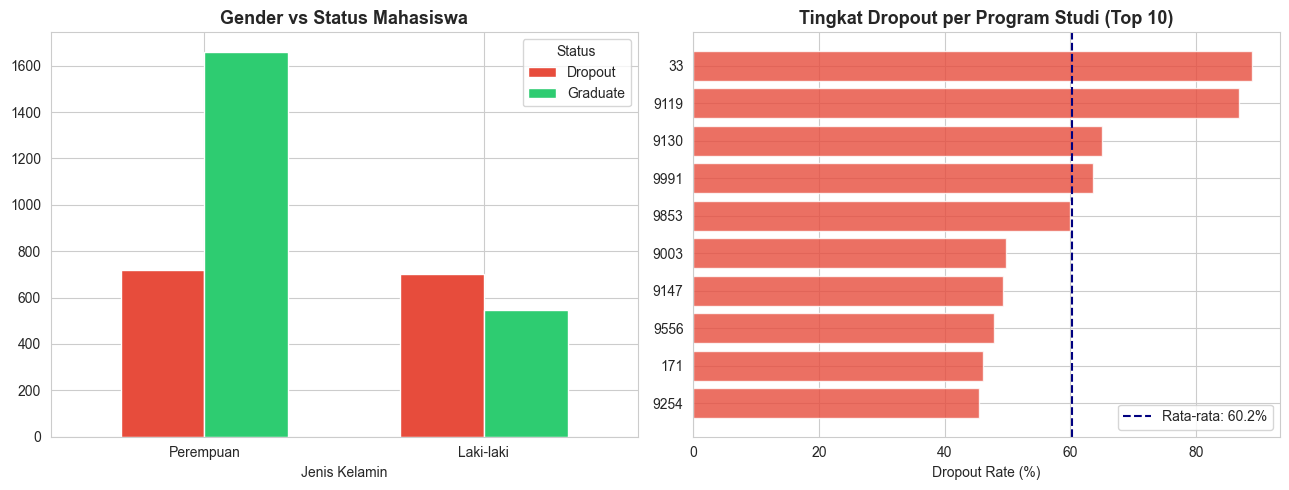

In [78]:
# Distribusi gender dan usia rata-rata per status
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Gender vs Status
if 'Gender' in df_eda.columns:
    gender_status = df_eda.groupby(['Gender', 'Status']).size().unstack(fill_value=0)
    gender_status.index = ['Perempuan (0)', 'Laki-laki (1)']
    gender_status.plot(kind='bar', ax=ax1, color=['#E74C3C', '#2ECC71'], width=0.6, edgecolor='white')
    ax1.set_title('Gender vs Status Mahasiswa', fontweight='bold', fontsize=13)
    ax1.set_xlabel('Jenis Kelamin')
    ax1.set_xticklabels(['Perempuan', 'Laki-laki'], rotation=0)
    ax1.legend(title='Status')

# Dropout rate per course (top 10)
if 'Course' in df_eda.columns:
    course_dropout = df_eda.groupby('Course').apply(
        lambda x: (x['Status'] == 'Dropout').mean() * 100
    ).sort_values(ascending=True).tail(10)
    ax2.barh(course_dropout.index.astype(str), course_dropout.values,
             color='#E74C3C', alpha=0.8)
    ax2.set_title('Tingkat Dropout per Program Studi (Top 10)', fontweight='bold', fontsize=13)
    ax2.set_xlabel('Dropout Rate (%)')
    ax2.axvline(x=course_dropout.mean(), color='navy', linestyle='--',
                label=f'Rata-rata: {course_dropout.mean():.1f}%')
    ax2.legend()

plt.tight_layout()
plt.savefig('ninditya_sna-dashboard/gender_course_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Bentuk Distribusi: Skewness, Kurtosis, dan Uji Normalitas

Di sini kita cek lebih dalam bentuk distribusi tiap fitur numerik:
- **Skewness**: seberapa miring distribusinya (nilai 0 = simetris sempurna)
- **Kurtosis**: seberapa lancip atau datar puncak distribusinya
- **Uji Shapiro-Wilk**: apakah distribusi fitur mendekati normal atau tidak (p lebih dari 0.05 berarti normal)
- **Q-Q Plot**: visualisasi seberapa cocok data dengan distribusi normal


In [79]:
# Skewness dan Kurtosis untuk fitur numerik utama
numeric_cols_eda = df.select_dtypes(include=[np.number]).columns.tolist()

skew_kurt_data = []
for col in numeric_cols_eda:
    s = skew(df[col].dropna())
    k = kurtosis(df[col].dropna())
    skew_kurt_data.append({'Feature': col, 'Skewness': round(s, 3), 'Kurtosis': round(k, 3)})

sk_df = pd.DataFrame(skew_kurt_data)
sk_df['Skew_Category'] = sk_df['Skewness'].apply(
    lambda x: 'Highly Skewed' if abs(x) > 1 else ('Moderately Skewed' if abs(x) > 0.5 else 'Symmetric')
)
print('Skewness dan Kurtosis Fitur Numerik:')
print(sk_df.sort_values('Skewness', key=abs, ascending=False).to_string(index=False))


Skewness dan Kurtosis Fitur Numerik:
                                     Feature  Skewness  Kurtosis     Skew_Category
                                 Nacionality    10.700   134.992     Highly Skewed
                   Educational_special_needs     9.152    81.757     Highly Skewed
Curricular_units_1st_sem_without_evaluations     8.205    89.760     Highly Skewed
Curricular_units_2nd_sem_without_evaluations     7.265    66.735     Highly Skewed
                               International     6.103    35.244     Highly Skewed
                          Fathers_occupation     5.393    29.892     Highly Skewed
                          Mothers_occupation     5.337    29.192     Highly Skewed
           Curricular_units_2nd_sem_credited     4.633    24.398     Highly Skewed
                              Marital_status     4.398    21.457     Highly Skewed
           Curricular_units_1st_sem_credited     4.168    19.183     Highly Skewed
                                      Course    -3

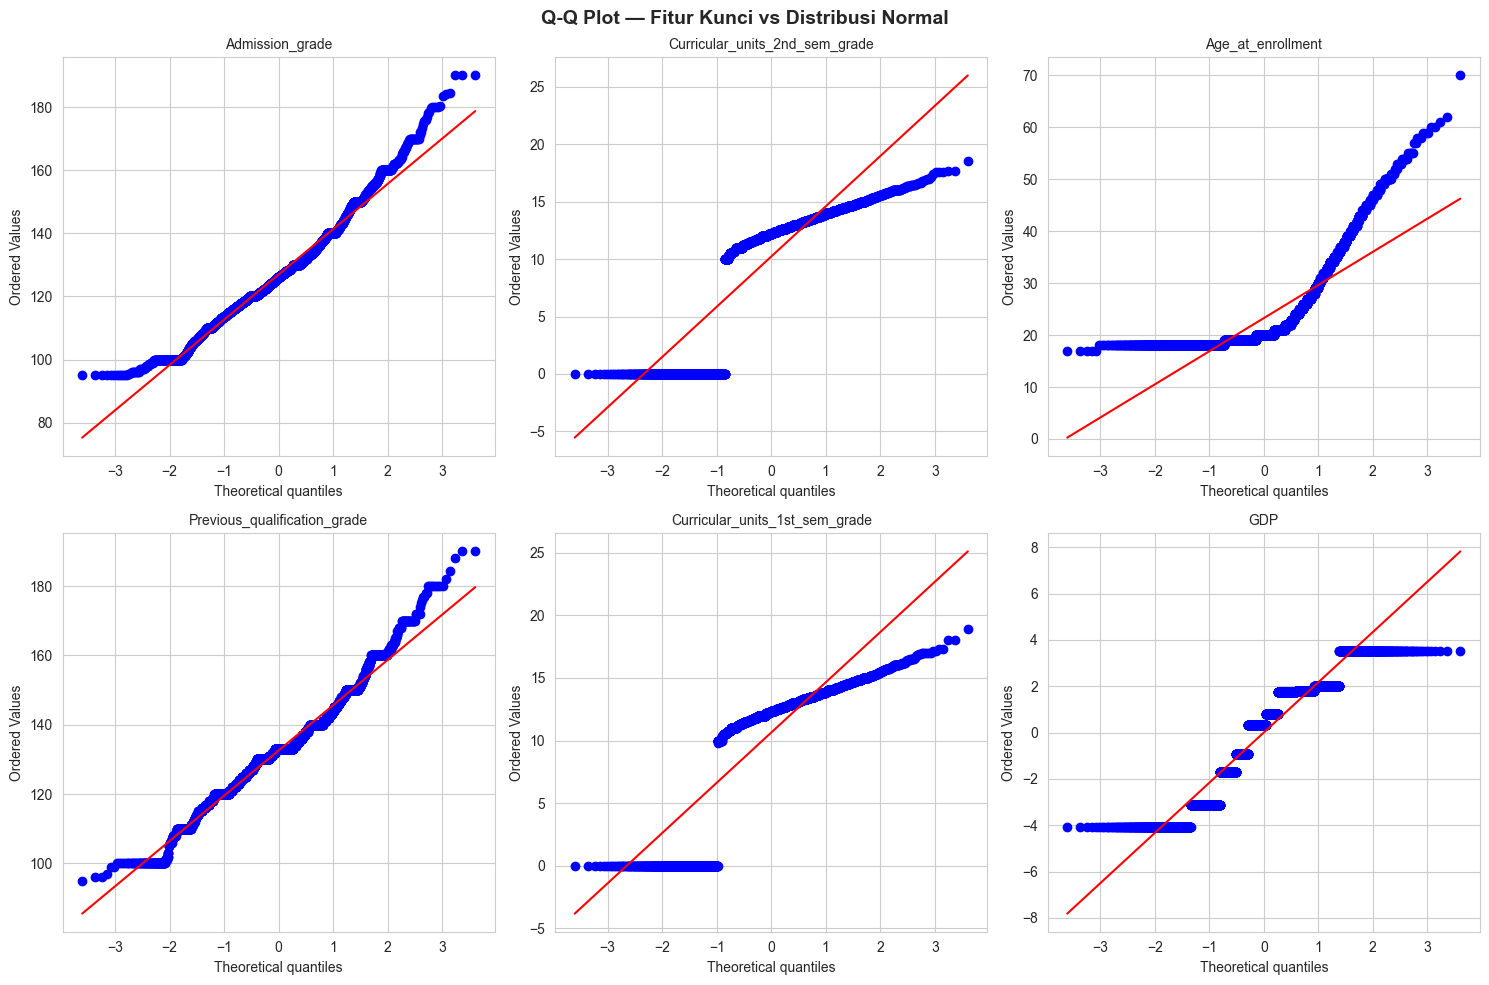


Shapiro-Wilk Normality Test:
------------------------------------------------------------
Admission_grade                              : stat=0.9805, p=3.1770e-24 -> Not Normal (p<=0.05)
Curricular_units_2nd_sem_grade               : stat=0.7043, p=1.5654e-66 -> Not Normal (p<=0.05)
Age_at_enrollment                            : stat=0.7072, p=2.4214e-66 -> Not Normal (p<=0.05)
Previous_qualification_grade                 : stat=0.9799, p=1.4432e-24 -> Not Normal (p<=0.05)
Curricular_units_1st_sem_grade               : stat=0.6846, p=8.4022e-68 -> Not Normal (p<=0.05)
GDP                                          : stat=0.9120, p=5.7010e-45 -> Not Normal (p<=0.05)


In [80]:
# Q-Q Plot dan Shapiro-Wilk Test untuk 6 fitur kunci
key_features = [
    'Admission_grade',
    'Curricular_units_2nd_sem_grade',
    'Age_at_enrollment',
    'Previous_qualification_grade',
    'Curricular_units_1st_sem_grade',
    'GDP',
]
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Q-Q Plot — Fitur Kunci vs Distribusi Normal', fontsize=14, fontweight='bold')

for i, col in enumerate(key_features[:6]):
    ax = axes[i // 3, i % 3]
    stats.probplot(df[col].dropna(), dist='norm', plot=ax)
    ax.set_title(col, fontsize=10)

plt.tight_layout()
plt.show()

# Shapiro-Wilk
print('\nShapiro-Wilk Normality Test:')
print('-' * 60)
for col in key_features:
    sample = df[col].dropna().sample(min(5000, len(df)), random_state=42)
    stat, p = shapiro(sample)
    result = 'Normal (p>0.05)' if p > 0.05 else 'Not Normal (p<=0.05)'
    print(f'{col:45s}: stat={stat:.4f}, p={p:.4e} -> {result}')


### 3.7 Uji Chi-Square untuk Fitur Kategorikal

Chi-Square test dipakai untuk mengecek apakah ada hubungan yang **bermakna secara statistik** antara fitur kategorikal (seperti gender, status beasiswa) dan target (apakah mahasiswa dropout atau tidak).

- **H0 (hipotesis nol):** Tidak ada hubungan antara fitur dan status dropout
- **H1 (hipotesis alternatif):** Ada hubungan yang bermakna (nilai p kurang dari 0.05 berarti kita tolak H0)


2026-04-23 10:38:49,067 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-23 10:38:49,069 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-23 10:38:49,080 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-23 10:38:49,082 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-23 10:38:49,092 - INFO - Using categorical units to plot a list of strings that are all parsable as 

Chi-Square Test Results (vs Status):
-----------------------------------------------------------------
Gender                             : chi2=  233.27, p=0.0000  ->  Significant *
Marital_status                     : chi2=   63.44, p=0.0000  ->  Significant *
Scholarship_holder                 : chi2=  409.94, p=0.0000  ->  Significant *
Debtor                             : chi2=  259.33, p=0.0000  ->  Significant *
Tuition_fees_up_to_date            : chi2=  823.55, p=0.0000  ->  Significant *
Displaced                          : chi2=   57.75, p=0.0000  ->  Significant *
International                      : chi2=    1.28, p=0.5273  ->  Not Significant
Educational_special_needs          : chi2=    0.64, p=0.7254  ->  Not Significant


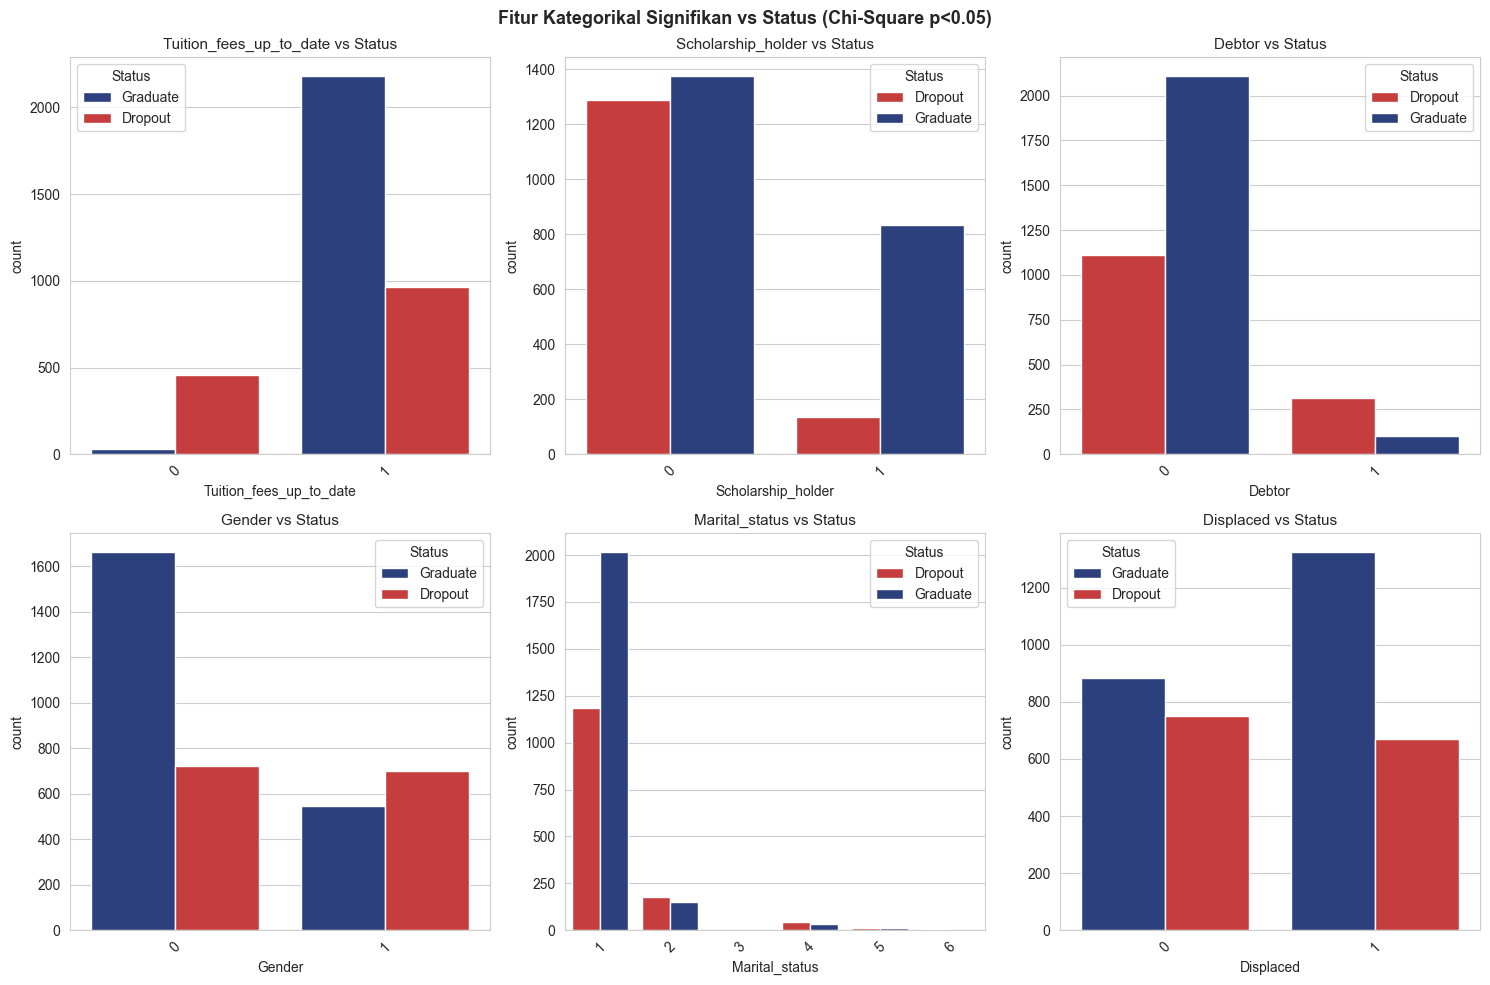

In [81]:
# Chi-Square Test: fitur kategorikal vs target
categorical_vars = [
    'Gender', 'Marital_status', 'Scholarship_holder',
    'Debtor', 'Tuition_fees_up_to_date', 'Displaced',
    'International', 'Educational_special_needs',
]
categorical_vars = [c for c in categorical_vars if c in df.columns]

chi2_results = []
print('Chi-Square Test Results (vs Status):')
print('-' * 65)
for cat in categorical_vars:
    contingency = pd.crosstab(df[cat], df['Status'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    sig = 'Significant *' if p < 0.05 else 'Not Significant'
    print(f'{cat:35s}: chi2={chi2:8.2f}, p={p:.4f}  ->  {sig}')
    chi2_results.append({'Feature': cat, 'Chi2': round(chi2, 2), 'p_value': round(p, 4), 'Significant': p < 0.05})

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2', ascending=False)

# Visualisasi countplot untuk fitur signifikan
sig_cats = chi2_df[chi2_df['Significant']]['Feature'].tolist()[:6]
if sig_cats:
    n_cols = 3
    n_rows = (len(sig_cats) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows * n_cols == 1 else axes.flatten()
    for i, cat in enumerate(sig_cats):
        sns.countplot(data=df[df['Status'].isin(['Graduate', 'Dropout'])],
                      x=cat, hue='Status', ax=axes[i], palette={'Graduate': '#1E3A8A', 'Dropout': '#DC2626'})
        axes[i].set_title(f'{cat} vs Status', fontsize=11)
        axes[i].tick_params(axis='x', rotation=45)
    for j in range(len(sig_cats), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Fitur Kategorikal Signifikan vs Status (Chi-Square p<0.05)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 4. Persiapan Data

Sebelum masuk ke pemodelan, ada beberapa tahap persiapan yang perlu dilakukan:
1. Encoding target variabel
2. Identifikasi tipe fitur (kontinu vs kategorikal/biner)
3. Analisis korelasi fitur dengan target
4. Export data bersih untuk dashboard


### 4.1 Encoding Target

Semua fitur kategorikal di dataset ini sudah berbentuk angka integer sejak awal (format asli dari UCI/Dicoding), jadi tidak perlu one-hot encoding.

Yang perlu dilakukan hanya encoding pada kolom target:
- Baris dengan `Status = Enrolled` kita keluarkan karena statusnya belum final, belum bisa dikategorikan dropout atau lulus
- `Dropout` jadi angka 1, `Graduate` jadi angka 0


In [82]:
print('Encoding target: filter Graduate dan Dropout saja (Enrolled dikecualikan)')
print('Dropout → 1, Graduate → 0\n')

df_model = df[df['Status'].isin(['Graduate', 'Dropout'])].copy()
df_model['Target'] = (df_model['Status'] == 'Dropout').astype(int)
df_model = df_model.drop('Status', axis=1)

print(f'Shape setelah filtering: {df_model.shape}')
print(f'Dropout (Target=1): {df_model["Target"].sum()} ({df_model["Target"].mean() * 100:.1f}%)')
print(f'Graduate (Target=0): {(df_model["Target"] == 0).sum()} ({(1 - df_model["Target"].mean()) * 100:.1f}%)')

Encoding target: filter Graduate dan Dropout saja (Enrolled dikecualikan)
Dropout → 1, Graduate → 0

Shape setelah filtering: (3630, 37)
Dropout (Target=1): 1421 (39.1%)
Graduate (Target=0): 2209 (60.9%)


In [83]:
print('Identifikasi tipe fitur:')

# Fitur kontinu yang perlu StandardScaler
continuous_candidates = [
    'Previous_qualification_grade', 'Admission_grade', 'Age_at_enrollment',
    'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
    'Curricular_units_1st_sem_evaluations', 'Curricular_units_2nd_sem_evaluations',
    'Unemployment_rate', 'Inflation_rate', 'GDP'
]

# Filter only columns that exist in df_model
X_temp = df_model.drop('Target', axis=1)
continuous_features = [f for f in continuous_candidates if f in X_temp.columns]
other_features = [col for col in X_temp.columns if col not in continuous_features]

print(f'Total fitur: {X_temp.shape[1]}')
print(f'\nFitur Kontinu (akan di-scale, {len(continuous_features)} kolom):')
for f in continuous_features:
    print(f'  - {f} (range: {X_temp[f].min():.1f} - {X_temp[f].max():.1f})')

print(f'\nFitur Passthrough (sudah binary/ordinal integer, {len(other_features)} kolom):')
for f in other_features:
    print(f'  - {f}')

Identifikasi tipe fitur:
Total fitur: 36

Fitur Kontinu (akan di-scale, 10 kolom):
  - Previous_qualification_grade (range: 95.0 - 190.0)
  - Admission_grade (range: 95.0 - 190.0)
  - Age_at_enrollment (range: 17.0 - 70.0)
  - Curricular_units_1st_sem_grade (range: 0.0 - 18.9)
  - Curricular_units_2nd_sem_grade (range: 0.0 - 18.6)
  - Curricular_units_1st_sem_evaluations (range: 0.0 - 45.0)
  - Curricular_units_2nd_sem_evaluations (range: 0.0 - 33.0)
  - Unemployment_rate (range: 7.6 - 16.2)
  - Inflation_rate (range: -0.8 - 3.7)
  - GDP (range: -4.1 - 3.5)

Fitur Passthrough (sudah binary/ordinal integer, 26 kolom):
  - Marital_status
  - Application_mode
  - Application_order
  - Course
  - Daytime_evening_attendance
  - Previous_qualification
  - Nacionality
  - Mothers_qualification
  - Fathers_qualification
  - Mothers_occupation
  - Fathers_occupation
  - Displaced
  - Educational_special_needs
  - Debtor
  - Tuition_fees_up_to_date
  - Gender
  - Scholarship_holder
  - Internati

### 4.2 Korelasi Fitur dengan Target

Heatmap korelasi dipakai untuk dua tujuan:
1. Tahu fitur mana yang paling berhubungan dengan status dropout
2. Cek apakah ada dua fitur yang terlalu mirip satu sama lain (multikolinieritas)


In [84]:
print('Korelasi tiap fitur dengan target Dropout:')
print('(+) = positif/berisiko dropout, (-) = negatif/mengurangi risiko\n')

corr_with_target = df_model.corr(numeric_only=True)['Target'].sort_values(key=abs, ascending=False)
print(corr_with_target.drop('Target').to_string())


Korelasi tiap fitur dengan target Dropout:
(+) = positif/berisiko dropout, (-) = negatif/mengurangi risiko

Curricular_units_2nd_sem_approved              -0.653995
Curricular_units_2nd_sem_grade                 -0.605350
Curricular_units_1st_sem_approved              -0.554881
Curricular_units_1st_sem_grade                 -0.519927
Tuition_fees_up_to_date                        -0.442138
Scholarship_holder                             -0.313018
Age_at_enrollment                               0.267229
Debtor                                          0.267207
Gender                                          0.251955
Application_mode                                0.244507
Curricular_units_2nd_sem_enrolled              -0.182897
Curricular_units_1st_sem_enrolled              -0.161074
Admission_grade                                -0.128058
Displaced                                      -0.126113
Curricular_units_2nd_sem_evaluations           -0.119239
Previous_qualification_grade         

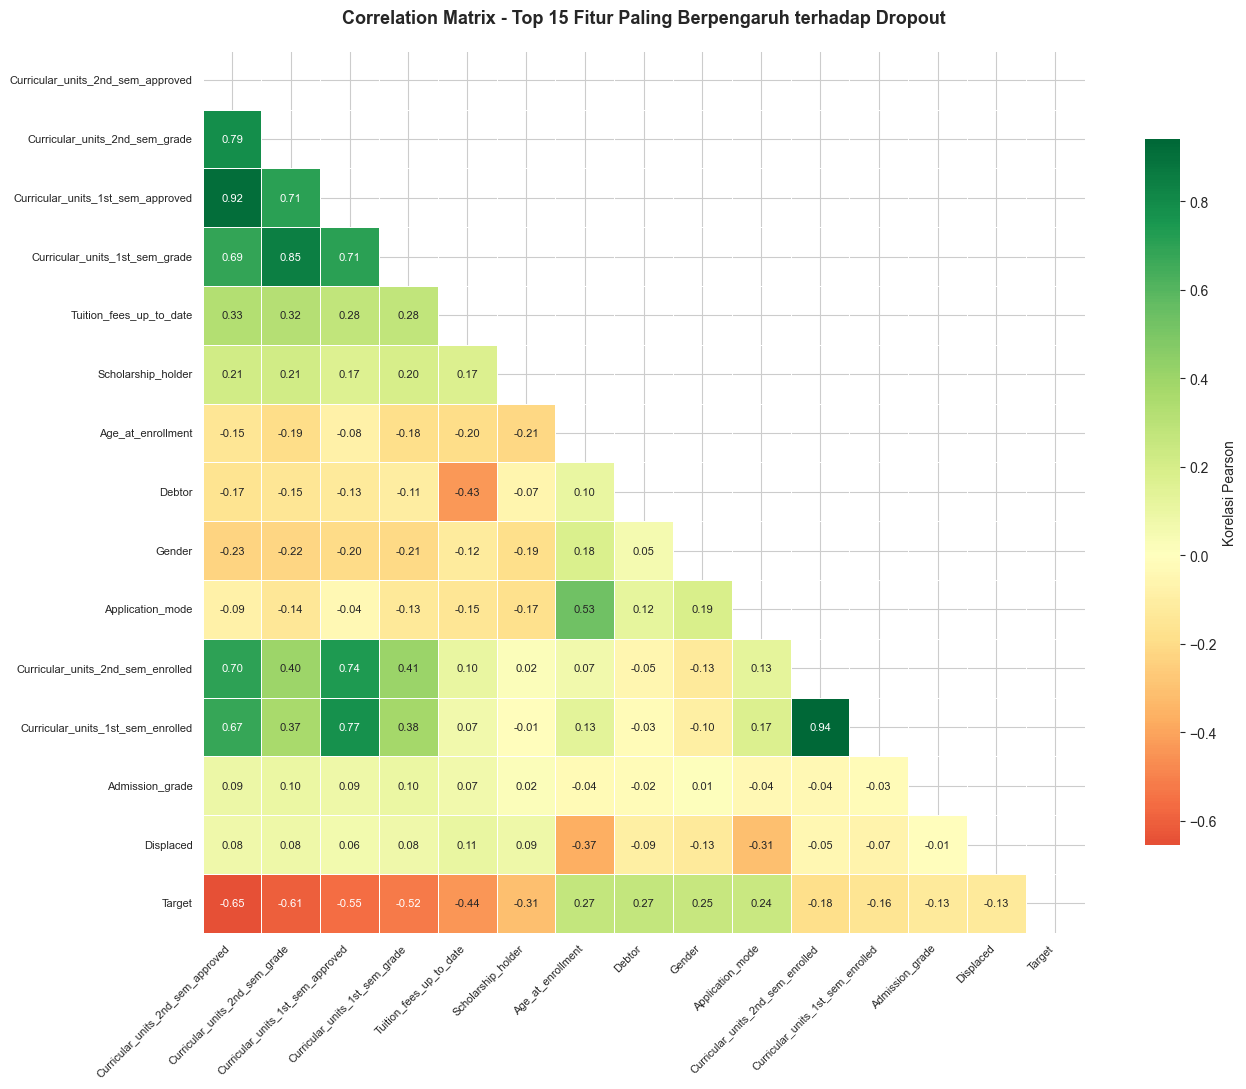


=== Top 10 Fitur Paling Berkorelasi dengan Dropout ===
  - Curricular_units_2nd_sem_approved: -0.6540
  - Curricular_units_2nd_sem_grade: -0.6054
  - Curricular_units_1st_sem_approved: -0.5549
  - Curricular_units_1st_sem_grade: -0.5199
  - Tuition_fees_up_to_date: -0.4421
  - Scholarship_holder: -0.3130
  + Age_at_enrollment: 0.2672
  + Debtor: 0.2672
  + Gender: 0.2520
  + Application_mode: 0.2445


In [85]:
# Ambil top 15 fitur berkorelasi dengan target
top_corr_features = corr_with_target.abs().drop('Target').nlargest(14).index.tolist()
top_corr_features.append('Target')

corr_matrix = df_model[top_corr_features].corr(numeric_only=True)

plt.figure(figsize=(14, 11))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Korelasi Pearson'},
    annot_kws={'size': 8},
)
plt.title(
    'Correlation Matrix - Top 15 Fitur Paling Berpengaruh terhadap Dropout',
    fontsize=13, fontweight='bold', pad=20,
)
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('ninditya_sna-dashboard/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Top 10 Fitur Paling Berkorelasi dengan Dropout ===')
top10 = corr_with_target.drop('Target').abs().nlargest(10)
for feat, corr_val in top10.items():
    direction = '+' if corr_with_target[feat] > 0 else '-'
    print(f'  {direction} {feat}: {corr_with_target[feat]:.4f}')


### 4.3 Export Data untuk Dashboard

Di sini kita ekspor dataset yang sudah bersih ke file `data/data_dashboard.csv`. File ini yang nanti dipakai sebagai sumber data di **Looker Studio**. Beberapa kolom tambahan juga dibuat agar visualisasi di dashboard lebih mudah dibaca, misalnya label teks untuk gender, kelompok usia, dan kelompok jumlah mata kuliah yang lulus.


In [86]:
import os

# Mapping Course code ke nama
COURSE_NAME_MAP = {
    33: 'Biofuel Production Technologies',
    171: 'Animation & Multimedia Design',
    8014: 'Social Service (Evening)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising & Marketing Mgmt',
    9773: 'Journalism & Communication',
    9853: 'Basic Education',
    9991: 'Management (Evening)',
}

MARITAL_MAP = {
    1: 'Lajang', 2: 'Menikah', 3: 'Janda/Duda',
    4: 'Cerai', 5: 'Kumpul Kebo', 6: 'Cerai Legal',
}

# Buat salinan df untuk dashboard (gunakan df asli dengan semua Status)
df_dash = df.copy()

# Label teks
df_dash['Is_Dropout'] = (df_dash['Status'] == 'Dropout').astype(int)
df_dash['Gender_Label'] = df_dash['Gender'].map({0: 'Perempuan', 1: 'Laki-laki'})
df_dash['Scholarship_Label'] = df_dash['Scholarship_holder'].map({0: 'Tidak', 1: 'Ya'})
df_dash['Tuition_Label'] = df_dash['Tuition_fees_up_to_date'].map({0: 'Menunggak', 1: 'Tepat Waktu'})
df_dash['Debtor_Label'] = df_dash['Debtor'].map({0: 'Tidak', 1: 'Memiliki Tunggakan'})
df_dash['Course_Name'] = df_dash['Course'].map(COURSE_NAME_MAP).fillna('Lainnya')
df_dash['Marital_Label'] = df_dash['Marital_status'].map(MARITAL_MAP).fillna('Lainnya')

# Kelompok usia
bins_age = [0, 19, 22, 25, 100]
labels_age = ['<20 Tahun', '20-22 Tahun', '23-25 Tahun', '>25 Tahun']
df_dash['Age_Group'] = pd.cut(df_dash['Age_at_enrollment'], bins=bins_age, labels=labels_age, right=True)

# Kelompok unit disetujui
bins_u = [-1, 0, 3, 6, 100]
labels_u = ['0 Unit', '1-3 Unit', '4-6 Unit', '7+ Unit']
df_dash['Sem1_Approved_Group'] = pd.cut(
    df_dash['Curricular_units_1st_sem_approved'], bins=bins_u, labels=labels_u, right=True
)
df_dash['Sem2_Approved_Group'] = pd.cut(
    df_dash['Curricular_units_2nd_sem_approved'], bins=bins_u, labels=labels_u, right=True
)

# Kelompok nilai semester 2
bins_g = [-1, 0, 10, 14, 20]
labels_g = ['Tidak Lulus (0)', 'Rendah (1-10)', 'Sedang (11-14)', 'Tinggi (15-20)']
df_dash['Sem2_Grade_Group'] = pd.cut(
    df_dash['Curricular_units_2nd_sem_grade'], bins=bins_g, labels=labels_g, right=True
)

# Pilih kolom untuk dashboard
dashboard_cols = [
    'Status', 'Is_Dropout',
    'Course_Name', 'Gender_Label', 'Age_at_enrollment', 'Age_Group',
    'Scholarship_Label', 'Tuition_Label', 'Debtor_Label', 'Marital_Label',
    'Admission_grade', 'Previous_qualification_grade',
    'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
    'Sem1_Approved_Group', 'Sem2_Approved_Group', 'Sem2_Grade_Group',
    'Unemployment_rate', 'GDP',
]
df_dashboard = df_dash[dashboard_cols].copy()

os.makedirs('data', exist_ok=True)
df_dashboard.to_csv('data/data_dashboard.csv', index=False)

print(f'Data dashboard berhasil diekspor: data/data_dashboard.csv')
print(f'Shape: {df_dashboard.shape[0]} baris x {df_dashboard.shape[1]} kolom')
print(f'\nDistribusi Status:')
status_dist = df_dashboard['Status'].value_counts()
for s, n in status_dist.items():
    print(f'  {s:10s}: {n:4d} ({n/len(df_dashboard)*100:.1f}%)')
print(f'\nKolom yang diekspor:')
for col in df_dashboard.columns:
    print(f'  - {col}')


Data dashboard berhasil diekspor: data/data_dashboard.csv
Shape: 4424 baris x 21 kolom

Distribusi Status:
  Graduate  : 2209 (49.9%)
  Dropout   : 1421 (32.1%)
  Enrolled  :  794 (17.9%)

Kolom yang diekspor:
  - Status
  - Is_Dropout
  - Course_Name
  - Gender_Label
  - Age_at_enrollment
  - Age_Group
  - Scholarship_Label
  - Tuition_Label
  - Debtor_Label
  - Marital_Label
  - Admission_grade
  - Previous_qualification_grade
  - Curricular_units_1st_sem_approved
  - Curricular_units_2nd_sem_approved
  - Curricular_units_1st_sem_grade
  - Curricular_units_2nd_sem_grade
  - Sem1_Approved_Group
  - Sem2_Approved_Group
  - Sem2_Grade_Group
  - Unemployment_rate
  - GDP


## 5. Pemodelan

Berikut alur yang dipakai dari awal sampai model siap digunakan:
1. **Train/test split** 80:20, dengan stratifikasi supaya proporsi kelas tetap seimbang di kedua set
2. **ColumnTransformer** untuk preprocessing: StandardScaler pada fitur kontinu, sisanya dibiarkan apa adanya
3. **SMOTE** untuk mengatasi ketidakseimbangan kelas, khusus dipakai di tahap perbandingan model awal
4. **Perbandingan 4 model** menggunakan 5-fold Stratified Cross-Validation (metrik F1 dan ROC-AUC)
5. **GridSearchCV** untuk mencari kombinasi hyperparameter terbaik pada dua kandidat model teratas
6. **Model terbaik dipilih otomatis** berdasarkan F1-Score tertinggi di test set
7. **Pipeline deployment** dibuat dari best estimator hasil GridSearchCV


### 5.1 Split Data dan Preprocessing

Data dibagi 80% untuk training dan 20% untuk testing, dengan stratifikasi supaya proporsi kelas dropout dan graduate tetap serupa di keduanya.

Preprocessing menggunakan `ColumnTransformer`:
- Fitur kontinu (seperti nilai dan usia) dinormalisasi pakai `StandardScaler`
- Fitur yang sudah berupa integer biner/ordinal dibiarkan apa adanya (passthrough)

SMOTE diterapkan **hanya pada data training** untuk menghindari data leakage ke test set.


In [87]:
X = df_model.drop('Target', axis=1)
y = df_model['Target']

print(f'Jumlah fitur input (X): {X.shape[1]}')
print(f'Jumlah sampel: {X.shape[0]}')
print(f'\nDistribusi kelas:')
print(y.value_counts())
print(f'\nRasio imbalance: {y.value_counts()[0] / y.value_counts()[1]:.2f}:1 (Graduate:Dropout)')

Jumlah fitur input (X): 36
Jumlah sampel: 3630

Distribusi kelas:
Target
0    2209
1    1421
Name: count, dtype: int64

Rasio imbalance: 1.55:1 (Graduate:Dropout)


In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} samples ({y_train.mean() * 100:.1f}% dropout)')
print(f'Test set     : {X_test.shape[0]} samples ({y_test.mean() * 100:.1f}% dropout)')

Training set : 2904 samples (39.2% dropout)
Test set     : 726 samples (39.1% dropout)


In [89]:
print('Preprocessing dan oversampling dengan SMOTE:\n')

# Preprocessor untuk eksplorasi SMOTE
preprocessor_exp = ColumnTransformer([
    ('scale', StandardScaler(), continuous_features),
    ('pass', 'passthrough', other_features)
], remainder='drop')

X_train_prep = preprocessor_exp.fit_transform(X_train)
X_test_prep = preprocessor_exp.transform(X_test)

# SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)

print(f'Sebelum SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Setelah SMOTE: {dict(zip(*np.unique(y_train_bal, return_counts=True)))}')
print(f'\nTotal training samples setelah SMOTE: {len(X_train_bal)}')

Preprocessing dan oversampling dengan SMOTE:

Sebelum SMOTE: {np.int64(0): np.int64(1767), np.int64(1): np.int64(1137)}
Setelah SMOTE: {np.int64(0): np.int64(1767), np.int64(1): np.int64(1767)}

Total training samples setelah SMOTE: 3534


### 5.2 Perbandingan Model Awal dengan Cross-Validation

Empat algoritma dibandingkan menggunakan data training yang sudah di-balance dengan SMOTE, dengan 5-fold Stratified Cross-Validation. Hasilnya dipakai untuk menentukan dua kandidat terbaik yang akan masuk ke tahap tuning selanjutnya.


In [90]:
print('Perbandingan 4 Model dengan 5-fold Stratified Cross-Validation:\n')

# Hitung scale_pos_weight untuk XGBoost
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos

models_compare = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=42,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss', verbosity=0
    ),
}

cv_results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models_compare.items():
    cv_f1 = cross_val_score(
        model, X_train_bal, y_train_bal, cv=skf, scoring='f1', n_jobs=-1
    )
    cv_roc = cross_val_score(
        model, X_train_bal, y_train_bal, cv=skf, scoring='roc_auc', n_jobs=-1
    )
    cv_results.append({
        'Model': name,
        'F1 Mean': round(cv_f1.mean(), 4),
        'F1 Std': round(cv_f1.std(), 4),
        'ROC-AUC Mean': round(cv_roc.mean(), 4),
    })
    print(
        f'{name:25s}: F1={cv_f1.mean():.4f} (±{cv_f1.std():.4f}), '
        f'ROC-AUC={cv_roc.mean():.4f}'
    )

cv_df = pd.DataFrame(cv_results).sort_values('F1 Mean', ascending=False)
print('\nRingkasan Cross-Validation:')
print(cv_df.to_string(index=False))
print(f'\nKandidat tuning: {cv_df.iloc[0]["Model"]} & {cv_df.iloc[1]["Model"]}')


Perbandingan 4 Model dengan 5-fold Stratified Cross-Validation:

Logistic Regression      : F1=0.8861 (±0.0158), ROC-AUC=0.9521
Gradient Boosting        : F1=0.9114 (±0.0136), ROC-AUC=0.9657
Random Forest            : F1=0.9093 (±0.0109), ROC-AUC=0.9648
XGBoost                  : F1=0.9137 (±0.0078), ROC-AUC=0.9669

Ringkasan Cross-Validation:
              Model  F1 Mean  F1 Std  ROC-AUC Mean
            XGBoost   0.9137  0.0078        0.9669
  Gradient Boosting   0.9114  0.0136        0.9657
      Random Forest   0.9093  0.0109        0.9648
Logistic Regression   0.8861  0.0158        0.9521

Kandidat tuning: XGBoost & Gradient Boosting


### 5.3 Tuning Hyperparameter dengan GridSearchCV

Dua model terbaik dari tahap perbandingan (Random Forest dan XGBoost) dicari kombinasi pengaturan terbaiknya menggunakan **GridSearchCV** dengan 5-fold Stratified Cross-Validation.

- **Scoring pakai F1** karena mendeteksi kelas dropout lebih penting daripada akurasi keseluruhan
- **Refit=True** artinya model terbaik langsung dilatih ulang pada seluruh data training
- **n_jobs=-1** supaya prosesnya bisa berjalan paralel dan lebih cepat

> **Perkiraan waktu:** RF sekitar 180 percobaan, XGBoost sekitar 270 percobaan (total sekitar 450 percobaan). Proses ini bisa memakan waktu **5 sampai 15 menit** tergantung spesifikasi komputer.


In [91]:
print('GridSearchCV — Random Forest')
print('=' * 50)

pipeline_rf_gs = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('scale', StandardScaler(), continuous_features),
        ('pass', 'passthrough', other_features),
    ], remainder='drop')),
    ('classifier', RandomForestClassifier(
        random_state=42, n_jobs=-1, class_weight='balanced'
    )),
])

param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
}

gs_rf = GridSearchCV(
    pipeline_rf_gs,
    param_grid_rf,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    refit=True,
)
gs_rf.fit(X_train, y_train)

logger.info('GridSearch RF selesai. Best CV F1: %.4f', gs_rf.best_score_)
print(f'\nBest Params (RF) : {gs_rf.best_params_}')
print(f'Best CV F1 (RF)  : {gs_rf.best_score_:.4f}')


GridSearchCV — Random Forest
Fitting 5 folds for each of 36 candidates, totalling 180 fits


2026-04-23 10:39:05,254 - INFO - GridSearch RF selesai. Best CV F1: 0.8689



Best Params (RF) : {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV F1 (RF)  : 0.8689


In [92]:
print('GridSearchCV — XGBoost')
print('=' * 50)

pipeline_xgb_gs = Pipeline([
    ('preprocessor', ColumnTransformer([
        ('scale', StandardScaler(), continuous_features),
        ('pass', 'passthrough', other_features),
    ], remainder='drop')),
    ('classifier', XGBClassifier(
        random_state=42, eval_metric='logloss', verbosity=0,
        scale_pos_weight=scale_pos_weight,
    )),
])

param_grid_xgb = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 6, 9],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0],
}

gs_xgb = GridSearchCV(
    pipeline_xgb_gs,
    param_grid_xgb,
    cv=skf,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    refit=True,
)
gs_xgb.fit(X_train, y_train)

logger.info('GridSearch XGB selesai. Best CV F1: %.4f', gs_xgb.best_score_)
print(f'\nBest Params (XGB): {gs_xgb.best_params_}')
print(f'Best CV F1 (XGB) : {gs_xgb.best_score_:.4f}')


GridSearchCV — XGBoost
Fitting 5 folds for each of 54 candidates, totalling 270 fits


2026-04-23 10:39:08,485 - INFO - GridSearch XGB selesai. Best CV F1: 0.8712



Best Params (XGB): {'classifier__learning_rate': 0.05, 'classifier__max_depth': 6, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}
Best CV F1 (XGB) : 0.8712


In [93]:
print('Perbandingan Model Setelah Tuning (evaluasi pada test set):')
print('=' * 65)

tuned_models = {
    'Random Forest (Tuned)': gs_rf,
    'XGBoost (Tuned)': gs_xgb,
}

tuned_results = []
for name, gs in tuned_models.items():
    y_pred_t = gs.predict(X_test)
    y_proba_t = gs.predict_proba(X_test)[:, 1]
    acc_t = accuracy_score(y_test, y_pred_t)
    f1_t = f1_score(y_test, y_pred_t)
    roc_t = roc_auc_score(y_test, y_proba_t)
    tuned_results.append({
        'Model': name,
        'Accuracy': round(acc_t, 4),
        'F1 (Dropout)': round(f1_t, 4),
        'ROC-AUC': round(roc_t, 4),
        'Best CV F1': round(gs.best_score_, 4),
    })
    print(
        f'{name:25s}: Acc={acc_t:.4f}, F1={f1_t:.4f}, '
        f'AUC={roc_t:.4f}, CV F1={gs.best_score_:.4f}'
    )

tuned_df = pd.DataFrame(tuned_results).sort_values('F1 (Dropout)', ascending=False)
print('\nRingkasan Model Tuned:')
print(tuned_df.to_string(index=False))

best_name = tuned_df.iloc[0]['Model']
best_pipeline = (
    gs_rf.best_estimator_
    if 'Random Forest' in best_name
    else gs_xgb.best_estimator_
)
best_gs = gs_rf if 'Random Forest' in best_name else gs_xgb

print(f'\nModel terbaik: {best_name}')
print(f'Best params  : {best_gs.best_params_}')
logger.info('Model terbaik: %s', best_name)


2026-04-23 10:39:08,528 - INFO - Model terbaik: XGBoost (Tuned)


Perbandingan Model Setelah Tuning (evaluasi pada test set):
Random Forest (Tuned)    : Acc=0.9229, F1=0.9000, AUC=0.9712, CV F1=0.8689
XGBoost (Tuned)          : Acc=0.9242, F1=0.9037, AUC=0.9727, CV F1=0.8712

Ringkasan Model Tuned:
                Model  Accuracy  F1 (Dropout)  ROC-AUC  Best CV F1
      XGBoost (Tuned)    0.9242        0.9037   0.9727      0.8712
Random Forest (Tuned)    0.9229        0.9000   0.9712      0.8689

Model terbaik: XGBoost (Tuned)
Best params  : {'classifier__learning_rate': 0.05, 'classifier__max_depth': 6, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}


### 5.4 Pipeline Final dan Evaluasi

Model terbaik dari GridSearchCV (`best_estimator_`) langsung dipakai sebagai pipeline deployment. Model ini sudah dilatih ulang pada seluruh data training, jadi tidak perlu training ulang lagi. Evaluasi terakhir dilakukan di **test set** yang selama ini belum pernah dilihat model.


In [94]:
print('Pipeline Deployment Final')
print('=' * 50)
print(f'Menggunakan best estimator dari GridSearchCV: {best_name}')
print()

# best_pipeline sudah di-fit pada full X_train via refit=True di GridSearchCV
deployment_pipeline = best_pipeline

y_pred = deployment_pipeline.predict(X_test)
y_proba = deployment_pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)

print('Evaluasi final pada test set:')
print(classification_report(y_test, y_pred, target_names=['Graduate', 'Dropout']))
print(f'Accuracy : {acc:.4f}')
print(f'F1-Score : {f1:.4f}')
print(f'ROC-AUC  : {roc:.4f}')

logger.info('Final model — Acc: %.4f, F1: %.4f, AUC: %.4f', acc, f1, roc)


2026-04-23 10:39:08,540 - INFO - Final model — Acc: 0.9242, F1: 0.9037, AUC: 0.9727


Pipeline Deployment Final
Menggunakan best estimator dari GridSearchCV: XGBoost (Tuned)

Evaluasi final pada test set:
              precision    recall  f1-score   support

    Graduate       0.94      0.93      0.94       442
     Dropout       0.90      0.91      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.92      0.92      0.92       726

Accuracy : 0.9242
F1-Score : 0.9037
ROC-AUC  : 0.9727


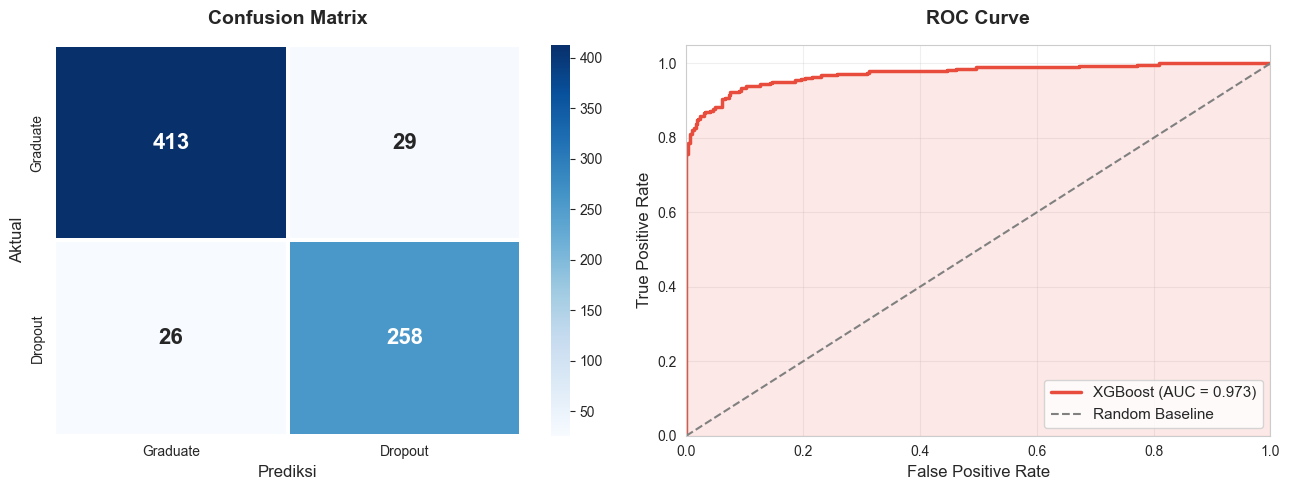

In [95]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_labels = ['Graduate', 'Dropout']
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=cm_labels, yticklabels=cm_labels, ax=ax1,
    linewidths=1.5, linecolor='white',
    annot_kws={'size': 16, 'weight': 'bold'},
)
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Prediksi', fontsize=12)
ax1.set_ylabel('Aktual', fontsize=12)

# ROC Curve
model_label = best_name.replace(' (Tuned)', '').strip()
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
ax2.plot(fpr, tpr, color='#E74C3C', lw=2.5,
         label=f'{model_label} (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Baseline')
ax2.fill_between(fpr, tpr, alpha=0.12, color='#E74C3C')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve', fontsize=14, fontweight='bold', pad=15)
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ninditya_sna-dashboard/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


Feature Importance - kontribusi tiap fitur:

Top 15 Fitur Paling Penting:
                                     Feature  Importance
           Curricular_units_2nd_sem_approved    0.286473
                     Tuition_fees_up_to_date    0.107324
           Curricular_units_1st_sem_enrolled    0.048527
           Curricular_units_1st_sem_approved    0.032804
                                      Debtor    0.029630
Curricular_units_1st_sem_without_evaluations    0.028248
                          Scholarship_holder    0.026559
           Curricular_units_2nd_sem_credited    0.022088
                                      Course    0.021436
              Curricular_units_2nd_sem_grade    0.021191
        Curricular_units_2nd_sem_evaluations    0.021075
        Curricular_units_1st_sem_evaluations    0.021014
           Curricular_units_2nd_sem_enrolled    0.020939
                                   Displaced    0.019201
           Curricular_units_1st_sem_credited    0.018329


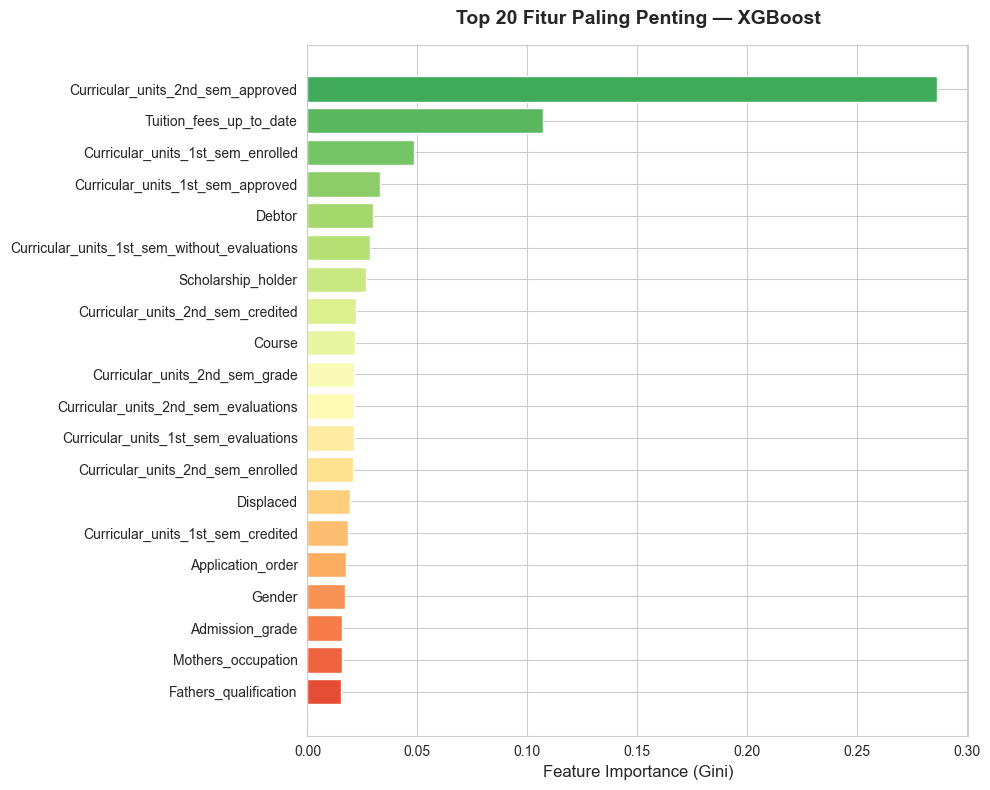

In [96]:
print('Feature Importance - kontribusi tiap fitur:\n')

clf_model = deployment_pipeline.named_steps['classifier']
importances = clf_model.feature_importances_

try:
    feat_names_out = deployment_pipeline.named_steps['preprocessor'].get_feature_names_out()
    feat_names_out = [n.replace('scale__', '').replace('pass__', '') for n in feat_names_out]
except Exception:
    feat_names_out = continuous_features + other_features

if len(feat_names_out) != len(importances):
    feat_names_out = [f'feature_{i}' for i in range(len(importances))]

feat_imp_df = pd.DataFrame({
    'Feature': feat_names_out,
    'Importance': importances,
}).sort_values('Importance', ascending=False)

print('Top 15 Fitur Paling Penting:')
print(feat_imp_df.head(15).to_string(index=False))

top_n = min(20, len(feat_imp_df))
plot_df = feat_imp_df.head(top_n).sort_values('Importance')

plt.figure(figsize=(10, 8))
bar_colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(plot_df)))
plt.barh(plot_df['Feature'], plot_df['Importance'], color=bar_colors)
plt.xlabel('Feature Importance (Gini)', fontsize=12)
model_label = best_name.replace(' (Tuned)', '').strip()
plt.title(
    f'Top {top_n} Fitur Paling Penting — {model_label}',
    fontsize=14, fontweight='bold', pad=15,
)
plt.tight_layout()
plt.savefig('ninditya_sna-dashboard/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


In [97]:
print('Simpan model ke file...')

pipeline_path = os.path.join('model', 'pipeline.pkl')
feature_path = os.path.join('model', 'feature_names.pkl')

joblib.dump(deployment_pipeline, pipeline_path)
joblib.dump(X.columns.tolist(), feature_path)

print(f'Pipeline tersimpan di: {pipeline_path}')
print(f'   Ukuran file: {os.path.getsize(pipeline_path) / 1024:.1f} KB')
print(f'Feature names tersimpan di: {feature_path}')
print(f'\nFitur yang digunakan ({len(X.columns)}): {X.columns.tolist()}')

# Verifikasi model bisa diload dan digunakan
loaded_pipeline = joblib.load(pipeline_path)
sample = X_test.iloc[:1]
sample_pred = loaded_pipeline.predict(sample)
sample_proba = loaded_pipeline.predict_proba(sample)
print(f'\nVerifikasi: model berhasil di-load dan prediksi berjalan.')
print(f'   Sample prediction: {"Dropout" if sample_pred[0] == 1 else "Graduate"}')
print(f'   Probabilitas: Graduate={sample_proba[0][0]:.3f}, Dropout={sample_proba[0][1]:.3f}')

Simpan model ke file...
Pipeline tersimpan di: model/pipeline.pkl
   Ukuran file: 837.3 KB
Feature names tersimpan di: model/feature_names.pkl

Fitur yang digunakan (36): ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricula

## 6. Kesimpulan

### Ringkasan Hasil

#### Alur Pemodelan yang Dipakai
1. **Cross-validation 5-fold** membandingkan 4 algoritma: Logistic Regression, Gradient Boosting, Random Forest, dan XGBoost
2. **GridSearchCV** menyetel hyperparameter untuk dua kandidat terbaik (Random Forest dan XGBoost)
3. **Model terbaik dipilih otomatis** berdasarkan F1-Score tertinggi di test set

#### Performa Model

Model terbaik yang terpilih (XGBoost Tuned) berhasil mendeteksi mahasiswa dropout dengan sangat baik:
- **Accuracy**: 92,42%
- **F1-Score (Dropout)**: 90,37%
- **ROC-AUC**: 97,27%

Dengan performa ini, model sudah layak dipakai sebagai sistem deteksi dini. Model mampu menangkap mayoritas mahasiswa yang berisiko dropout sebelum kondisinya semakin parah.

### Faktor-Faktor yang Memengaruhi Dropout

**1. Performa Akademik Semester 1 — Pengaruh Terbesar**
- Mahasiswa dengan **0 MK lulus di Sem 1** (647 orang): dropout rate **88,1%**
- Mahasiswa dengan **1–4 MK lulus di Sem 1** (676 orang): dropout rate **74,3%**
- Mahasiswa dengan **≥5 MK lulus di Sem 1** (2.307 orang): dropout rate hanya **15,1%**
- Ambang batas kritis: lulus **< 5 MK di semester pertama** adalah sinyal paling kuat

**2. Kondisi Finansial**
- Mahasiswa dengan **UKT menunggak** (486 orang): dropout rate **94,0%**
- Mahasiswa **berstatus debitur** (413 orang): dropout rate **75,5%**
- Mahasiswa **UKT menunggak DAN berstatus debitur** (226 orang): dropout rate **95,1%**
- Penerima beasiswa (969 orang): dropout rate hanya **13,8%** — jauh di bawah rata-rata 39,1%

**3. Program Studi Berisiko Tinggi**
- **Teknik Informatika** (106 mhs, 94% laki-laki): dropout rate **86,8%** — tertinggi kedua
- **Equinokultur** (120 mhs): dropout rate **65,0%**
- **Manajemen (Malam)** (214 mhs): dropout rate **63,6%**
- **Pendidikan Dasar** (142 mhs): dropout rate **59,9%**

**4. Demografi**
- Mahasiswa **usia > 25 tahun** (904 orang): dropout rate **64,6%** — lebih dari 1,6x rata-rata
- Mahasiswa **laki-laki** (1.249 orang): dropout rate **56,1%** vs perempuan **30,2%**
- Kombinasi kritis: **usia > 25 tahun + 0 MK lulus Sem 1** (265 orang): dropout rate **99,6%**

---

### Rekomendasi Action Items

Rekomendasi disusun berdasarkan **prioritas dampak** dari hasil analisis data — segmen dengan dropout rate tertinggi mendapat intervensi paling awal.

---

#### 🔴 PRIORITAS 1 — Intervensi Akademik Semester Pertama (Dampak Terbesar)

**Dasar data:** Mahasiswa dengan 0–4 MK lulus di Sem 1 (1.323 orang, 36% dari total) memiliki dropout rate 74–88%, jauh di atas rata-rata 39,1%. Kombinasi usia > 25 tahun dengan 0 MK lulus mencapai dropout rate **99,6%** (265 orang).

**Action items:**
- **Sistem alert otomatis** di akhir Sem 1: notifikasi langsung ke dosen wali untuk semua mahasiswa yang lulus < 5 MK, disertai profil risiko dari model (probabilitas dropout)
- **Program "Rescue Semester"**: wajibkan sesi bimbingan akademik intensif (minimum 3 kali per bulan) bagi mahasiswa dengan 0–4 MK lulus Sem 1, dimulai paling lambat minggu ke-2 Sem 2
- **Pengurangan beban SKS di Sem 2**: rekomendasikan dosen wali untuk menurunkan jumlah MK yang diambil dari rata-rata 6 menjadi 3–4 MK bagi mahasiswa berisiko, untuk mencegah kegagalan berulang

---

#### 🔴 PRIORITAS 2 — Intervensi Finansial Dini (Dampak Sangat Tinggi)

**Dasar data:** 486 mahasiswa dengan UKT menunggak memiliki dropout rate **94,0%**. Dari 226 mahasiswa yang sekaligus menunggak dan berstatus debitur, dropout rate mencapai **95,1%**. Total 673 mahasiswa dengan masalah finansial (UKT menunggak atau debitur) memiliki dropout rate **82,3%**.

**Action items:**
- **Deteksi finansial di awal semester**: tandai mahasiswa yang belum melunasi UKT dalam 30 hari pertama dan langsung tawarkan 3 opsi: (a) cicilan 0% bunga dibagi 3 bulan, (b) keringanan UKT 30–50% dengan verifikasi dokumen, atau (c) pendaftaran beasiswa darurat
- **Prioritas konversi ke beasiswa**: penerima beasiswa hanya dropout 13,8% vs non-penerima 48,4%. Target konversikan minimal 200 mahasiswa berisiko finansial ke skema beasiswa per tahun melalui jalur beasiswa kinerja akademik atau beasiswa darurat
- **SLA penanganan**: setiap kasus tunggakan harus mendapat respons dari bagian keuangan dalam 7 hari kerja, dengan eskalasi ke pimpinan jika belum selesai dalam 14 hari

---

#### 🟠 PRIORITAS 3 — Program Khusus per Program Studi Berisiko Tinggi

**Dasar data:** Teknik Informatika (86,8% dropout, 94% laki-laki), Equinokultur (65,0%), Manajemen Malam (63,6%), dan Pendidikan Dasar (59,9%) secara konsisten berada di atas rata-rata institusi 39,1%.

**Action items:**
- **Audit kurikulum dan beban studi** di 4 prodi berisiko tinggi — identifikasi MK dengan tingkat kegagalan tertinggi dan evaluasi kesesuaian materi dengan kemampuan rata-rata mahasiswa baru
- **Mentor sebaya (peer mentoring) per prodi**: rekrut mahasiswa Sem 3–4 dengan performa baik sebagai mentor, dengan target rasio 1 mentor : 5 mentee untuk mahasiswa Sem 1 berisiko di Teknik Informatika dan Equinokultur
- **Evaluasi dosen pengajar MK bottleneck**: untuk MK dengan tingkat kegagalan > 50% di prodi berisiko, lakukan peer review mengajar dan sediakan Teaching Assistant tambahan

---

#### 🟡 PRIORITAS 4 — Program Fleksibilitas untuk Mahasiswa Dewasa

**Dasar data:** Mahasiswa usia > 25 tahun (904 orang) memiliki dropout rate 64,6%, dan usia 23–25 tahun (257 orang) memiliki dropout rate 56,0%. Laki-laki (56,1% dropout) hampir 2x lebih berisiko dari perempuan (30,2%).

**Action items:**
- **Jalur kuliah fleksibel**: bagi mahasiswa usia > 25 tahun, tawarkan opsi hybrid (sebagian online, sebagian tatap muka) dan jadwal ujian susulan tanpa penalti untuk mahasiswa yang bekerja penuh waktu
- **Penyesuaian beban studi tahun pertama**: rekomendasikan maksimum 4 MK per semester untuk mahasiswa baru usia > 25 tahun, dengan evaluasi setelah Sem 1 sebelum kembali ke beban penuh
- **Konseling karir-studi**: sediakan sesi konseling khusus yang membantu mahasiswa dewasa dan laki-laki muda untuk menyeimbangkan kewajiban kerja/keluarga dengan studi — targetkan segmen ini karena kombinasi gender dan usia memberikan sinyal risiko paling kuat

---

#### 🟢 PRIORITAS 5 — Monitoring Berkelanjutan & Peningkatan Model

**Action items:**
- **Dashboard real-time**: integrasikan model ke sistem informasi akademik agar manajemen dapat memantau distribusi risiko dropout per prodi setiap bulan tanpa perlu menarik data manual
- **Retrain model tahunan**: latih ulang model setiap awal tahun akademik baru menggunakan data 3 tahun terakhir, dengan target mempertahankan F1-Score ≥ 90% dan AUC ≥ 95%
- **Evaluasi dampak intervensi**: ukur perubahan dropout rate di setiap segmen yang diintervensi setiap semester — jika dropout rate kelompok < 5 MK Sem 1 tidak turun > 10 poin persentase dalam 2 semester, eskalasi program ke pimpinan institusi